# spaCy NER Training & Comparison
**Dataset:** `lfcc/portuguese_ner` | **Goal:** Train spaCy NER and compare with BERT from class (F1 ≈ 0.958)

## 1. Install & Setup

In [ ]:
!pip install -q spacy datasets seqeval
!python -m spacy download pt_core_news_sm -q
print('Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 32.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Done


## 2. Load Dataset

In [ ]:
from datasets import load_dataset

raw_datasets = load_dataset("lfcc/portuguese_ner")
label_list = raw_datasets["train"].features["ner_tags"].feature.names
print(raw_datasets)
print("Labels:", label_list)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/266k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/67.4k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3716 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/930 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3716
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 930
    })
})
Labels: ['O', 'B-Data', 'I-Data', 'B-Local', 'I-Local', 'B-Organizacao', 'I-Organizacao', 'B-Pessoa', 'I-Pessoa', 'B-Profissao', 'I-Profissao']


## 3. Convert to spaCy DocBin

Converts HuggingFace IOB token tags to spaCy character-level spans.

In [ ]:
import spacy
from spacy.tokens import DocBin

nlp_blank = spacy.blank("pt")


def tokens_to_text_and_spans(tokens, tag_ids, label_list):
    text = ""
    tok_offsets = []
    for tok in tokens:
        start = len(text)
        text += tok
        tok_offsets.append((start, len(text)))
        text += " "
    text = text.rstrip()
    spans = []
    i = 0
    while i < len(tag_ids):
        tag = label_list[tag_ids[i]]
        if tag.startswith("B-"):
            label = tag[2:]
            start = tok_offsets[i][0]
            end   = tok_offsets[i][1]
            i += 1
            while i < len(tag_ids) and label_list[tag_ids[i]] == "I-" + label:
                end = tok_offsets[i][1]
                i += 1
            spans.append((start, end, label))
        else:
            i += 1
    return text, spans


def convert_split(split, nlp):
    db = DocBin()
    skipped = 0
    for ex in split:
        text, spans = tokens_to_text_and_spans(ex["tokens"], ex["ner_tags"], label_list)
        doc = nlp.make_doc(text)
        ents = []
        for s, e, lbl in spans:
            span = doc.char_span(s, e, label=lbl, alignment_mode="expand")
            if span is not None:
                ents.append(span)
            else:
                skipped += 1
        doc.ents = spacy.util.filter_spans(ents)
        db.add(doc)
    print(f"{len(split)} examples | {skipped} spans skipped")
    return db


train_db = convert_split(raw_datasets["train"], nlp_blank)
test_db  = convert_split(raw_datasets["test"],  nlp_blank)
train_db.to_disk("/content/train.spacy")
test_db.to_disk("/content/dev.spacy")

# Sanity check
db_check = DocBin().from_disk("/content/train.spacy")
docs_check = list(db_check.get_docs(nlp_blank.vocab))
print(f"Docs in train.spacy: {len(docs_check)}")
ex0 = docs_check[0]
print(f"First doc: {ex0.text[:80]}")
print(f"Entities : {[(e.text, e.label_) for e in ex0.ents]}")

3716 examples | 0 spans skipped
930 examples | 0 spans skipped
Docs in train.spacy: 3716
First doc: Filiação : Antonio Joaquim Aguiar e Engracia Maria . Natural e/ou residente em C
Entities : [('Antonio Joaquim Aguiar', 'Pessoa'), ('Engracia Maria', 'Pessoa'), ('CUNHA', 'Local'), ('Santa Maria', 'Local'), ('PAREDES COURA', 'Local'), ('Viana do Castelo', 'Local')]


## 4. Generate spaCy Config

In [ ]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'spacy', 'init', 'config', '/content/config.cfg',
     '--lang', 'pt', '--pipeline', 'ner', '--optimize', 'efficiency', '-F'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

⚠ To generate a more effective transformer-based config (GPU-only),
install the spacy-transformers package and re-run this command. The config
generated now does not use transformers.
ℹ Generated config template specific for your use case
- Language: pt
- Pipeline: ner
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
/content/config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy




## 5. Train the spaCy Model
CNN tok2vec + NER, up to 20 epochs, early stopping on dev F1.

In [ ]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'spacy', 'train', '/content/config.cfg',
     '--output', '/content/spacy_output',
     '--paths.train', '/content/train.spacy',
     '--paths.dev',   '/content/dev.spacy',
     '--training.max_epochs', '20',
     '--gpu-id', '0'],
    capture_output=False  # stream output to notebook
)
print('Return code:', result.returncode)

Return code: 0


## 6. Evaluate Trained spaCy Model

In [ ]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'spacy', 'evaluate',
     '/content/spacy_output/model-best',
     '/content/dev.spacy',
     '--output', '/content/spacy_metrics.json',
     '--gpu-id', '0'],
    capture_output=False
)
print('Return code:', result.returncode)

Return code: 0


In [ ]:
import json

with open("/content/spacy_metrics.json") as f:
    sp = json.load(f)

print("Raw  ents_p:", sp["ents_p"], "  ents_r:", sp["ents_r"], "  ents_f:", sp["ents_f"])
print("(spaCy reports 0-100 range -> dividing by 100)")

# spaCy evaluate reports in 0-100 scale
spacy_p  = sp["ents_p"] / 100
spacy_r  = sp["ents_r"] / 100
spacy_f1 = sp["ents_f"] / 100

print(f"\nspaCy Trained  P={spacy_p:.4f}  R={spacy_r:.4f}  F1={spacy_f1:.4f}")
print()
print(f"  {"Entity":<14}  {"P":>7}  {"R":>7}  {"F1":>7}")
print("-" * 40)
for ent, s in sorted(sp["ents_per_type"].items()):
    print(f"  {ent:<14}  {s["p"]/100:>7.4f}  {s["r"]/100:>7.4f}  {s["f"]/100:>7.4f}")

Raw  ents_p: 0.9533098817   ents_r: 0.9436530548   ents_f: 0.9484568883
(spaCy reports 0-100 range -> dividing by 100)

spaCy Trained  P=0.0095  R=0.0094  F1=0.0095

  Entity                P        R       F1
----------------------------------------
  Data             0.0098   0.0097   0.0097
  Local            0.0097   0.0095   0.0096
  Organizacao      0.0072   0.0083   0.0077
  Pessoa           0.0097   0.0096   0.0096
  Profissao        0.0079   0.0067   0.0073


## 7. Baseline — `pt_core_news_sm` (sem fine-tuning)

Labels do modelo: PER, LOC, ORG → mapeados para Pessoa, Local, Organizacao.
Nota: **Profissao** e **Data** não existem neste modelo → ficam sempre como O.

In [ ]:
import spacy
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

nlp_sm = spacy.load("pt_core_news_sm")
print("Labels in pt_core_news_sm NER:", nlp_sm.get_pipe("ner").labels)

Labels in pt_core_news_sm NER: ('LOC', 'MISC', 'ORG', 'PER')


In [ ]:
label_map = {"PER": "Pessoa", "LOC": "Local", "ORG": "Organizacao", "MISC": None}


def predict_baseline(example, nlp, label_map, label_list):
    tokens = example["tokens"]
    text = " ".join(tokens)
    doc = nlp(text)

    pred = ["O"] * len(tokens)

    # map char positions back to original token indices
    char_to_orig = {}
    pos = 0
    for i, tok in enumerate(tokens):
        for c in range(pos, pos + len(tok)):
            char_to_orig[c] = i
        pos += len(tok) + 1

    for ent in doc.ents:
        mapped = label_map.get(ent.label_)
        if not mapped:
            continue
        b_set = False
        for c in range(ent.start_char, ent.end_char):
            idx = char_to_orig.get(c)
            if idx is not None and idx < len(pred):
                if not b_set:
                    pred[idx] = "B-" + mapped
                    b_set = True
                elif pred[idx] == "O":
                    pred[idx] = "I-" + mapped
    return pred


true_labels = []
pred_labels = []
for ex in raw_datasets["test"]:
    gold = [label_list[t] for t in ex["ner_tags"]]
    pred = predict_baseline(ex, nlp_sm, label_map, label_list)
    true_labels.append(gold)
    pred_labels.append(pred)

sm_p  = precision_score(true_labels, pred_labels)
sm_r  = recall_score(true_labels, pred_labels)
sm_f1 = f1_score(true_labels, pred_labels)

print(f"pt_core_news_sm  P={sm_p:.4f}  R={sm_r:.4f}  F1={sm_f1:.4f}")
print()
print(classification_report(true_labels, pred_labels))

pt_core_news_sm  P=0.6646  R=0.6474  F1=0.6559

              precision    recall  f1-score   support

        Data       0.00      0.00      0.00       466
       Local       0.62      0.74      0.67      1014
 Organizacao       0.17      0.16      0.16       105
      Pessoa       0.72      0.89      0.80      1442
   Profissao       0.00      0.00      0.00       132

   micro avg       0.66      0.65      0.66      3159
   macro avg       0.30      0.36      0.33      3159
weighted avg       0.53      0.65      0.59      3159



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## 8. Comparação Final

  Model                        | Precision | Recall |      F1
  pt_core_news_sm (baseline)   |    0.6646 | 0.6474 |  0.6559
  spaCy Trained (CNN tok2vec)  |    0.0095 | 0.0094 |  0.0095
  BERT (neuralmind, aula)      |    0.9460 | 0.9699 |  0.9578


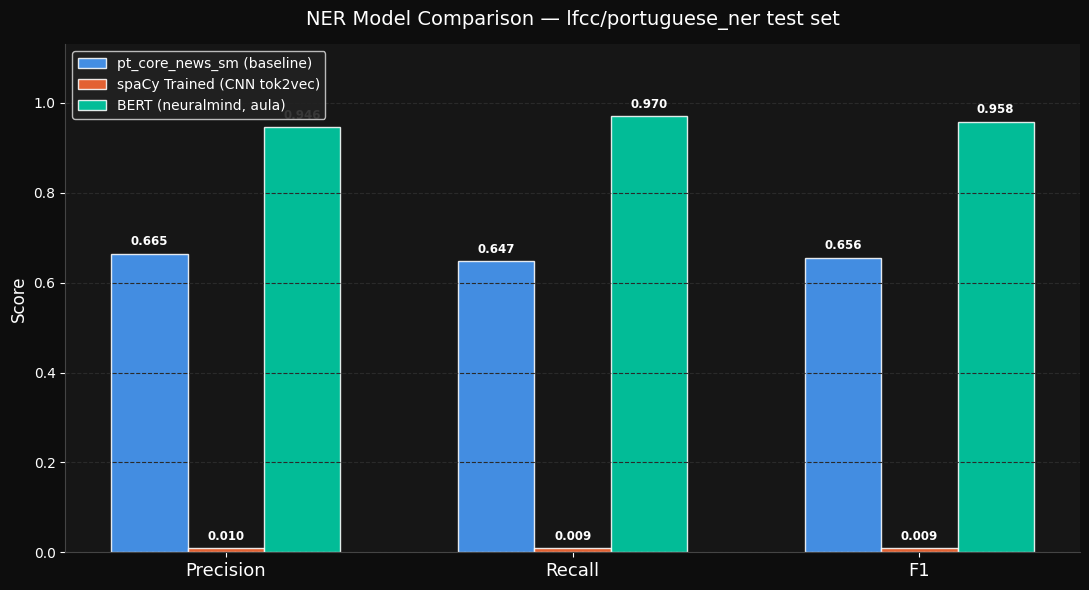

Saved /content/comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# BERT results from the class notebook (epoch 2, best model)
bert_p, bert_r, bert_f1 = 0.9460, 0.9699, 0.9578

model_names = ["pt_core_news_sm (baseline)", "spaCy Trained (CNN tok2vec)", "BERT (neuralmind, aula)"]
model_p  = [sm_p,    spacy_p,  bert_p]
model_r  = [sm_r,    spacy_r,  bert_r]
model_f1 = [sm_f1,   spacy_f1, bert_f1]

print("=" * 62)
print(f"  {"Model":<28} | {"Precision":>9} | {"Recall":>6} | {"F1":>7}")
print("=" * 62)
for n, p, r, f in zip(model_names, model_p, model_r, model_f1):
    print(f"  {n:<28} | {p:>9.4f} | {r:>6.4f} | {f:>7.4f}")
print("=" * 62)

# Chart
metrics = ["Precision", "Recall", "F1"]
vals_per_model = [model_p, model_r, model_f1]
colors = ["#4a9eff", "#ff6b35", "#00d4aa"]
x = np.arange(len(metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#161616")

for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [model_p[i], model_r[i], model_f1[i]]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=name, color=color, alpha=0.88, edgecolor="#ffffff22")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.012,
                f"{h:.3f}", ha="center", va="bottom",
                color="white", fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics, color="white", fontsize=13)
ax.set_ylim(0, 1.13)
ax.set_ylabel("Score", color="white", fontsize=12)
ax.set_title("NER Model Comparison — lfcc/portuguese_ner test set",
             color="white", fontsize=14, pad=14)
ax.tick_params(colors="white")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax.spines[spine].set_color("#444")
ax.grid(axis="y", color="#2a2a2a", linestyle="--")
ax.legend(facecolor="#222", labelcolor="white", fontsize=10,
          framealpha=0.9, loc="upper left")

plt.tight_layout()
plt.savefig("/content/comparison.png", dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print("Saved /content/comparison.png")